# 05 - Method Comparison and Findings

Every estimator in the repo, run on the same panel. The sensitivity of the
answer to method choice is itself the key finding in this literature - a
single point estimate understates how contested the true effect is (see
Card & Krueger 1994 vs. Neumark & Wascher 2000 for the canonical
disagreement).


In [1]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))
# Data vintage: which raw inputs produced everything below. LAUS is
# revised, so an executed notebook has to carry its own provenance.
from src.data.manifest import format_manifest

print(format_manifest())


Data vintage recorded 2026-08-10T23:01:47+00:00
  BLS LAUS API v1, 2000-2022, measures unemployment_rate, labor_force
  Minimum wage source: Vaghul-Zipperer https://github.com/benzipperer/historicalminwage/releases/download/v1.4.0/mw_state_excel.zip
  bls_unemployment: d8a672e371b6... (110,329 bytes, modified 2026-08-10T22:58:45+00:00)
  user_minimum_wage_csv: absent
  vz_minimum_wage: 5176fbe0fe04... (1,022,044 bytes, modified 2026-07-26T01:22:57+00:00)


## Putting the estimators on one scale

The estimators do not natively answer the same question. TWFE and the
border-discontinuity design regress unemployment on *log minimum wage*, so
their coefficients are semi-elasticities. Callaway-Sant'Anna, the event
study, and synthetic control estimate the effect of a *binary* treatment -
being a state whose minimum wage binds above the federal floor - and are
already in percentage points.

`src/methods/comparison.py` converts the first group by the average log
gap between the state and federal minimum among treated state-years, so
every row below is the same quantity: the average treatment effect on the
treated, in percentage points of unemployment.

In [2]:
import pandas as pd

from src.data.loader import load_state_year_panel
from src.methods.border_discontinuity import US_STATE_BORDER_PAIRS
from src.methods.comparison import build_comparison

panel, is_synthetic = load_state_year_panel()
print(f"panel: {'synthetic' if is_synthetic else 'real'}, {len(panel)} rows")

comparison = build_comparison(
    panel, border_pairs=US_STATE_BORDER_PAIRS, n_boot=500
)
factor = comparison.attrs['log_wage_gap']
print(f'conversion factor (mean treated log wage gap): {factor:.4f}')

comparison.assign(method=comparison.method.str.replace('\n', ' '))

panel: real, 1173 rows


conversion factor (mean treated log wage gap): 0.1782


,method,estimate,ci_lower,ci_upper,scale,note
0,TWFE DiD (log minimum wage),0.102564,-0.110630,0.315758,converted,semi-elasticity x 0.178 mean treated log wage gap
1,TWFE DiD (binary treatment),0.357121,0.011790,0.702452,native,absorbing above-federal indicator; comparable ...
2,Event study (post-period avg),0.468895,0.075683,0.862106,native,"contrast over 6 post coefficients, 15 never-tr..."
3,Callaway-Sant'Anna,0.556135,0.144261,0.968010,native,"overall ATT, 500 cluster bootstrap draws"
4,Synthetic control (avg over adopters),0.637528,0.317368,0.957687,conditional,21 adopters vs 15 never-treated donors (3 drop...
5,Border discontinuity,-0.014876,-0.182220,0.152468,converted,"109 contiguous pairs, pair + period FE, two-wa..."


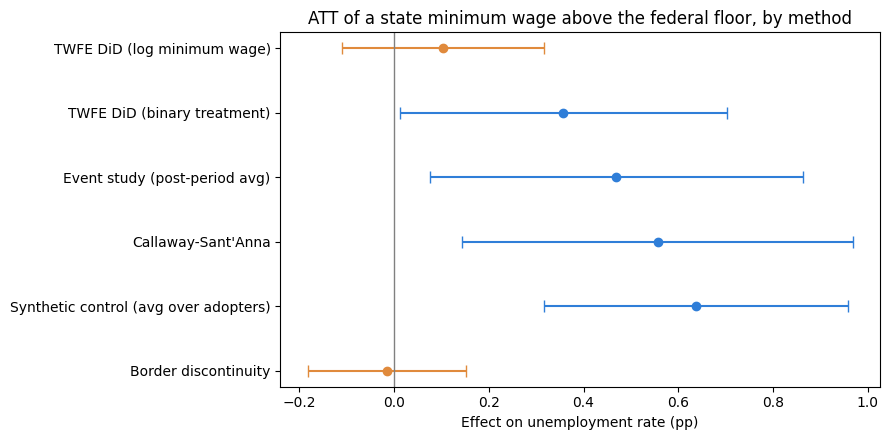

In [3]:
import matplotlib.pyplot as plt

df = comparison[comparison.scale != 'failed'].copy()
df['method'] = df.method.str.replace('\n', ' ')

fig, ax = plt.subplots(figsize=(9, 4.5))
y = range(len(df))
colors = ['#e08a3c' if s == 'converted' else '#2f7ed8' for s in df.scale]
for yi, row, color in zip(y, df.itertuples(), colors):
    ax.errorbar(row.estimate, yi,
                xerr=[[row.estimate - row.ci_lower], [row.ci_upper - row.estimate]],
                fmt='o', capsize=4, color=color)
ax.axvline(0, color='gray', linewidth=1)
ax.set_yticks(list(y)); ax.set_yticklabels(df.method)
ax.invert_yaxis()
ax.set_xlabel('Effect on unemployment rate (pp)')
ax.set_title('ATT of a state minimum wage above the federal floor, by method')
plt.tight_layout()
plt.show()

## Does the design survive its own diagnostics?

Point estimates are only worth reading if the identifying assumption
holds. Two checks: are the pre-treatment event-study coefficients jointly
zero, and is the estimate distinguishable from what randomly-timed
treatment produces?

In [4]:
from src.diagnostics.parallel_trends import pretrend_joint_test
from src.methods.event_study import estimate_event_study

es_result, es = estimate_event_study(panel)
joint = pretrend_joint_test(es_result, es)
screen = joint['individual_screen']
print(f"leads tested jointly:           {joint['leads_tested']}")
print(f"Wald chi2({joint['df']}):                 {joint['statistic']:.2f}")
print(f"p-value:                        {joint['p_value']:.3f}")
print(f"no detectable pre-trend:        {joint['passes']}")
print()
print(f"pre-treatment periods screened: {screen['n_pre_periods']}")
print(f"whose own CI excludes zero:     {screen['n_significant_violations']} "
      f"{screen['violating_periods']}")

leads tested jointly:           [-5, -4, -3, -2]
Wald chi2(4):                 3.70
p-value:                        0.449
no detectable pre-trend:        True

pre-treatment periods screened: 4
whose own CI excludes zero:     0 []


In [5]:
from src.diagnostics.parallel_trends import placebo_test
from src.methods.twfe_did import estimate_twfe

placebos = placebo_test(panel, estimate_twfe, n_placebos=60, seed=0)
actual = estimate_twfe(panel).params['log_minimum_wage']
share = (placebos.abs() >= abs(actual)).mean()
print(f'TWFE semi-elasticity:                            {actual:+.4f}')
print(f'placebo draws: {len(placebos)}, mean {placebos.mean():+.4f}, '
      f'sd {placebos.std():.4f}')
print(f'share at least this large in magnitude:          {share:.0%}')

TWFE semi-elasticity:                            +0.5755
placebo draws: 60, mean +0.0525, sd 0.5497
share at least this large in magnitude:          38%


In [6]:
from src.diagnostics.robustness import leave_one_state_out

loo = leave_one_state_out(panel, estimate_twfe)
coefs = loo.coef_without_state
print(f'full-sample coefficient:           {actual:+.4f}')
print(f'range across leave-one-out refits: [{coefs.min():+.4f}, {coefs.max():+.4f}]')
print(f'refits with the opposite sign:     {(coefs * actual < 0).sum()} of {len(loo)}')
loo.head(10)  # already sorted by |delta from full|

full-sample coefficient:           +0.5755
range across leave-one-out refits: [+0.3502, +0.8147]
refits with the opposite sign:     0 of 51


,dropped_state,coef_without_state,delta_from_full
0,RI,0.814710,0.239249
1,NV,0.350216,-0.225245
2,SC,0.402631,-0.172829
3,AK,0.415840,-0.159621
4,ND,0.734272,0.158811
5,AL,0.432699,-0.142762
6,CA,0.707876,0.132415
7,WY,0.701432,0.125972
8,PA,0.681887,0.106426
9,ID,0.472624,-0.102836


## Interpretation

Read the spread, not the point estimate. Three things to check against the
output above:

- **Do the intervals overlap?** Estimates that agree across identification
  strategies are worth more than any single one. Where they diverge, the
  divergence localises the problem: TWFE vs. Callaway-Sant'Anna isolates
  staggered-timing bias, TWFE vs. the border design isolates confounding
  regional shocks.
- **Do the intervals straddle zero?** If so the design cannot rule out no
  effect, whatever the point estimate's sign.
- **Does the placebo distribution contain the estimate?** If randomly-timed
  treatment reproduces an effect this large a substantial fraction of the
  time, the estimate is not evidence of a policy effect - it is evidence
  that state-year unemployment is autocorrelated enough to generate
  spurious ones.

A caveat that no diagnostic in this repo can address: states choose when
to raise their minimum wage, and they tend to do it when their labour
markets are strong. Every estimate here is conditional on parallel trends
surviving that selection.